In [1]:
CSV_SIG = '/n/holystore01/LABS/iaifi_lab/Lab/kyoon/BNSReg/00_AI4GW_TALK/ZZ_misc_outputs/00_AI4GW_TALK/mass_merger_sig/plots/param_est_results.csv'
CSV_BKG = '/n/holystore01/LABS/iaifi_lab/Lab/kyoon/BNSReg/00_AI4GW_TALK/ZZ_misc_outputs/00_AI4GW_TALK/mass_merger_bkg/plots/param_est_results.csv'

In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120,
})

df = pd.read_csv(CSV_SIG)
print(f'{len(df):,} events  |  columns: {list(df.columns)}')

# ── parse columns automatically ───────────────────────────────────────────────
vars_      = [c.replace('_true', '') for c in df.columns if c.endswith('_true')]
true_d     = {v: df[f'{v}_true'].values    for v in vars_}
pred_d     = {v: df[f'{v}_pred'].values    for v in vars_}
residual_d = {v: df[f'{v}_residual'].values for v in vars_}

sigma_d  = {c.removeprefix('sigma_').removesuffix('_pred'): df[c].values
            for c in df.columns if c.startswith('sigma_') and c.endswith('_pred')}
zscore_d = {c.removesuffix('_zscore'): df[c].values
            for c in df.columns if c.endswith('_zscore')}

snr = df['snr'].values if 'snr' in df.columns else None

# ── display helpers ───────────────────────────────────────────────────────────
VAR_LABELS = {
    'chirp_mass': r'$\mathcal{M}_c\,[M_\odot]$',
    'mass_ratio': r'$q$',
}
BINS = {
    'chirp_mass': np.linspace(0.5, 3.0, 51),
    'mass_ratio': np.linspace(0.0, 1.0, 51),
}

def label(v):
    return VAR_LABELS.get(v, v)

def bins_for(v, data):
    if v in BINS:
        b = BINS[v]
        if data.max() < b[0] or data.min() > b[-1]:
            return np.linspace(data.min(), data.max(), len(b))
        return b
    return np.linspace(data.min(), data.max(), 51)

def hist_outline(ax, data, bins, **kw):
    c, e = np.histogram(data, bins=bins)
    ax.stairs(c, e, **kw)

n = len(vars_)
df.head(3)

100,000 events  |  columns: ['chirp_mass_true', 'mass_ratio_true', 'chirp_mass_pred', 'mass_ratio_pred', 'sigma_chirp_mass_pred', 'sigma_mass_ratio_pred', 'chirp_mass_residual', 'mass_ratio_residual', 'chirp_mass_zscore', 'mass_ratio_zscore', 'snr']


,chirp_mass_true,mass_ratio_true,chirp_mass_pred,mass_ratio_pred,sigma_chirp_mass_pred,sigma_mass_ratio_pred,chirp_mass_residual,mass_ratio_residual,chirp_mass_zscore,mass_ratio_zscore,snr
0,1.216118,0.605457,1.194065,0.756480,0.015235,0.134585,-0.022053,0.151024,-1.447519,1.122145,22.053020
1,1.665317,0.797975,1.720627,0.806484,0.012921,0.105165,0.055309,0.008509,4.280554,0.080915,41.950680
2,1.506810,0.896340,1.525513,0.739726,0.011209,0.147307,0.018702,-0.156614,1.668457,-1.063179,35.749702


## True vs Predicted Histograms

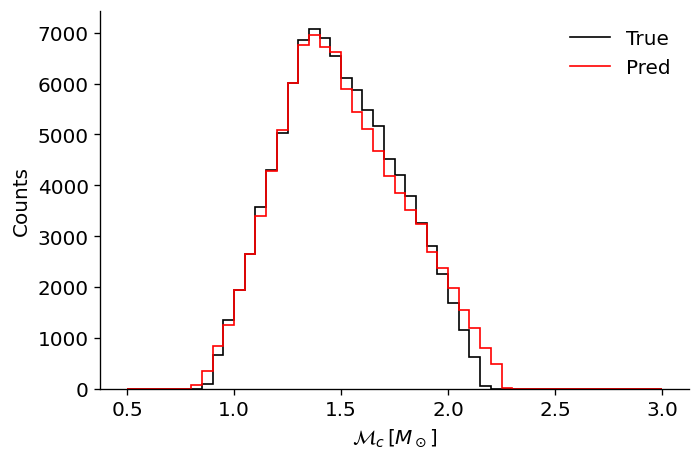

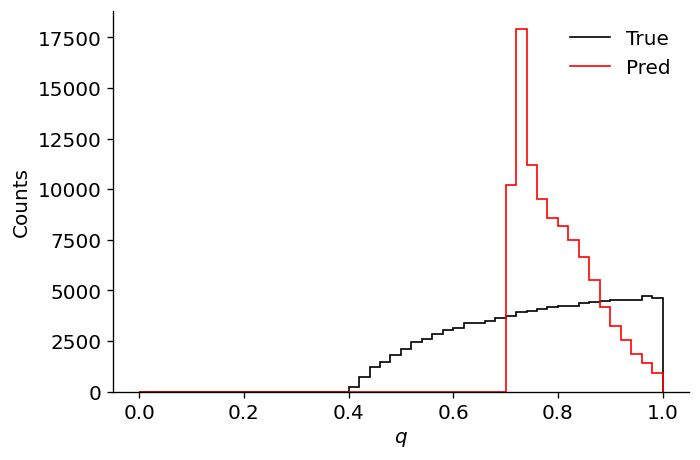

In [3]:
for v in vars_:
    bins = bins_for(v, true_d[v])

    fig, ax = plt.subplots(figsize=(6, 4))
    hist_outline(ax, true_d[v], bins, color='black', lw=1, label='True')
    hist_outline(ax, pred_d[v], bins, color='red',   lw=1, label='Pred')
    ax.set_xlabel(label(v))
    ax.set_ylabel('Counts')
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()

## Predicted vs True (Mean ± 68% Band)

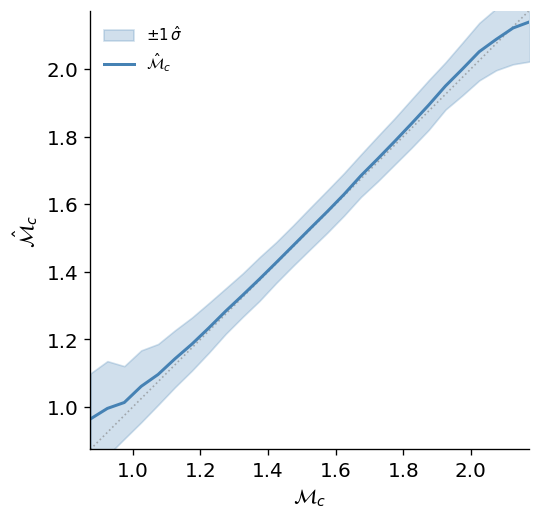

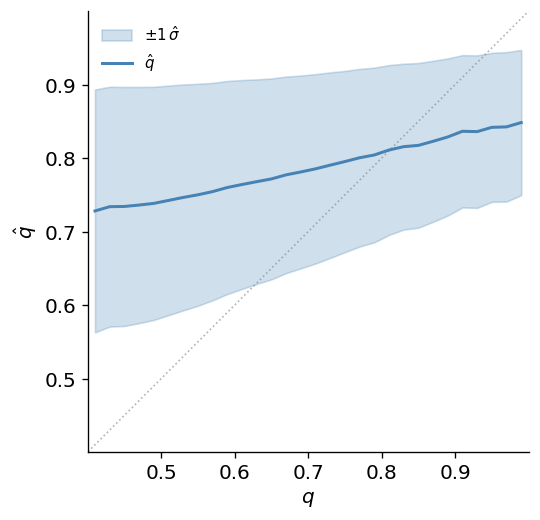

In [4]:
VAR_LABELS_UNITLESS = {
    'chirp_mass': r'$\mathcal{M}_c$',
    'mass_ratio': r'$q$',
}

VAR_LABELS_HAT = {
    'chirp_mass': r'$\hat{\mathcal{M}}_c$',
    'mass_ratio': r'$\hat{q}$',
}

def label_unitless(v):
    return VAR_LABELS_UNITLESS.get(v, v)

def label_hat(v):
    return VAR_LABELS_HAT.get(v, v)

for v in vars_:
    edges   = bins_for(v, true_d[v])
    centers = 0.5 * (edges[:-1] + edges[1:])
    tr, pr  = true_d[v], pred_d[v]
    sig     = sigma_d.get(v)

    mean_p    = np.full(len(centers), np.nan)
    mean_sig  = np.full(len(centers), np.nan)

    for i, (lo, hi) in enumerate(zip(edges[:-1], edges[1:])):
        m = (tr >= lo) & (tr < hi)
        if m.sum() < 2: continue
        mean_p[i]   = np.mean(pr[m])
        if sig is not None:
            mean_sig[i] = np.mean(sig[m])

    valid  = ~np.isnan(mean_p)
    lo_d, hi_d = float(tr.min()), float(tr.max())

    fig, ax = plt.subplots(figsize=(5, 4.5))
    ax.plot([lo_d, hi_d], [lo_d, hi_d], color='gray', lw=1.0, ls=':', alpha=0.6)

    if sig is not None and not np.all(np.isnan(mean_sig)):
        ax.fill_between(centers[valid],
                        mean_p[valid] - mean_sig[valid],
                        mean_p[valid] + mean_sig[valid],
                        alpha=0.25, color='steelblue', label=r'$\pm1\,\hat{\sigma}$')
    ax.plot(centers[valid], mean_p[valid], color='steelblue', lw=1.8,
            label=label_hat(v))

    ax.set_xlim(lo_d, hi_d); ax.set_ylim(lo_d, hi_d); ax.set_aspect('equal')
    ax.set_xlabel(label_unitless(v))
    ax.set_ylabel(label_hat(v))
    ax.legend(frameon=False, fontsize=9)
    fig.tight_layout()
    plt.show()


## Predicted Uncertainty (σ) Histograms

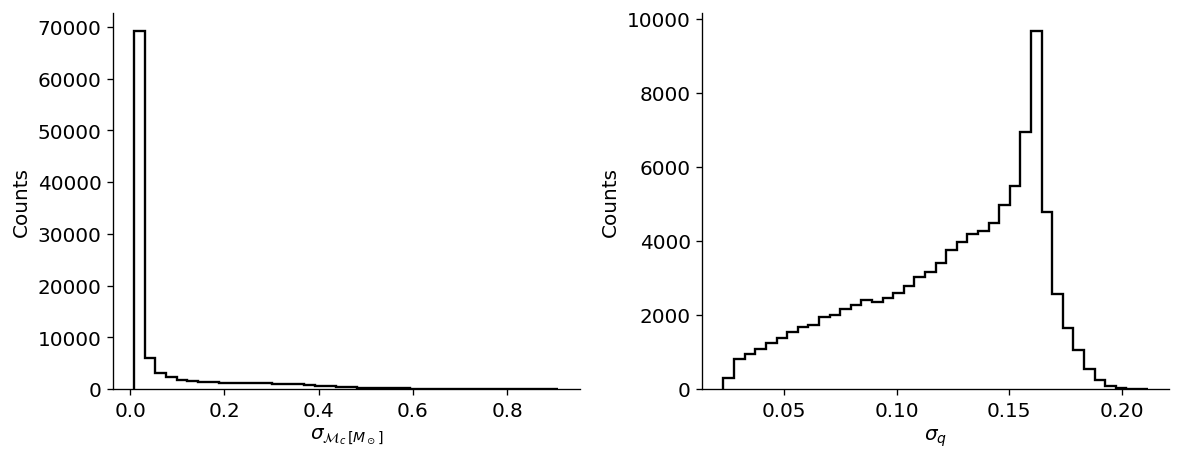

In [5]:
if sigma_d:
    ncols = min(n, 4); nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), squeeze=False)
    for ax, v in zip(axes.flat, vars_):
        if v in sigma_d:
            hist_outline(ax, sigma_d[v], bins=40, color='black', lw=1.4)
            lbl = label(v).strip('$')
            ax.set_xlabel(rf'$\sigma_{{{lbl}}}$'); ax.set_ylabel('Counts')
    for ax in axes.flat[n:]: ax.set_visible(False)
    fig.tight_layout()
    plt.show()
else:
    print('No sigma columns in CSV.')

## Z-Score Histograms
Ideal: unit Gaussian centred at 0.

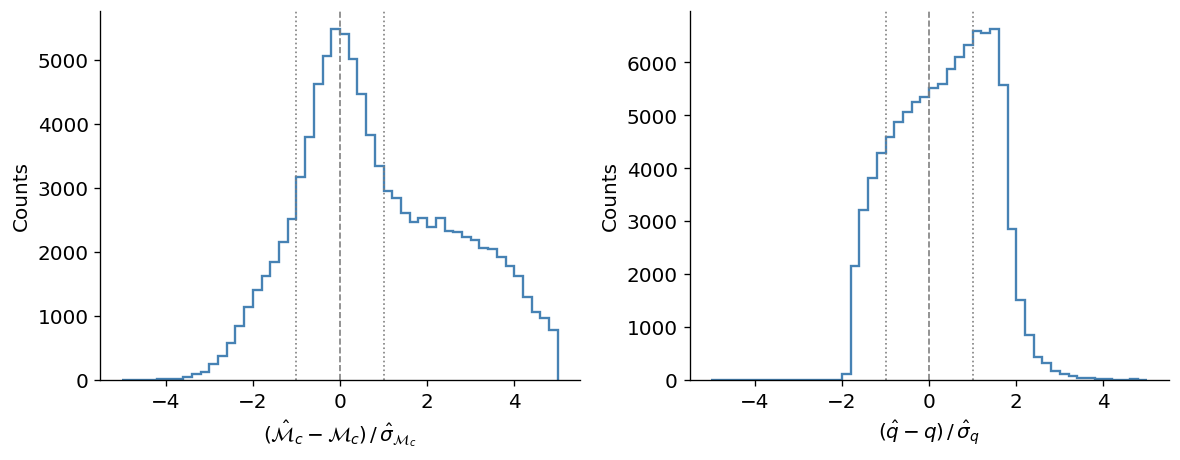

In [6]:
ZSCORE_XLABELS = {
    'chirp_mass': r'$(\hat{\mathcal{M}}_c - \mathcal{M}_c)\,/\,\hat{\sigma}_{\mathcal{M}_c}$',
    'mass_ratio': r'$(\hat{q} - q)\,/\,\hat{\sigma}_q$',
}

if zscore_d:
    ncols = min(n, 4); nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), squeeze=False)
    for ax, v in zip(axes.flat, vars_):
        if v in zscore_d:
            hist_outline(ax, zscore_d[v], bins=np.linspace(-5, 5, 51),
                         color='steelblue', lw=1.4)
            ax.axvline( 0, color='gray', ls='--',     lw=1.0)
            ax.axvline( 1, color='gray', ls='dotted', lw=1.0)
            ax.axvline(-1, color='gray', ls='dotted', lw=1.0)
            ax.set_xlabel(ZSCORE_XLABELS.get(v, v))
            ax.set_ylabel('Counts')
    for ax in axes.flat[n:]: ax.set_visible(False)
    fig.tight_layout()
    plt.show()
else:
    print('No z-score columns in CSV.')

## SNR-Binned Residuals (Median ± 68%)

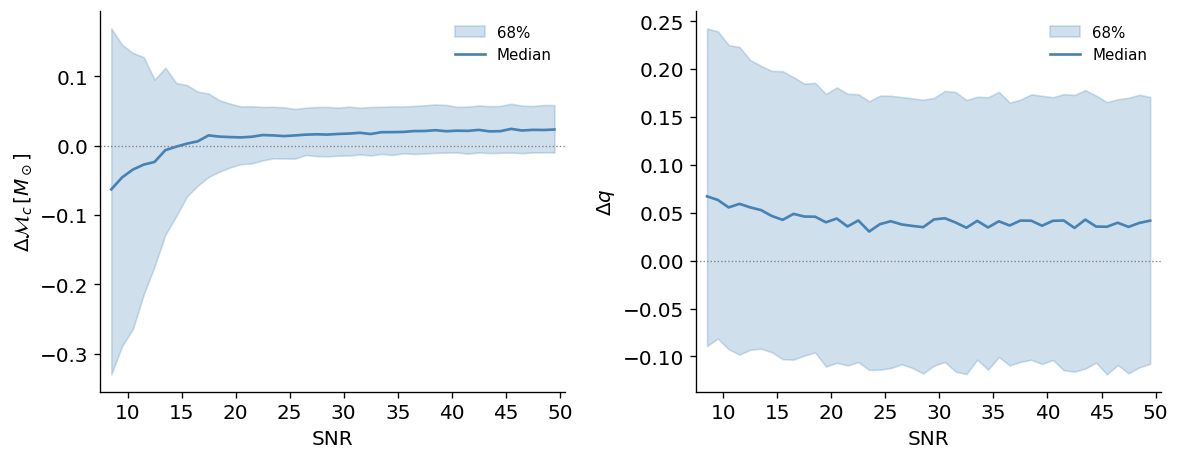

In [7]:
if snr is not None:
    snr_bins    = np.arange(int(np.floor(snr.min())), int(np.ceil(snr.max())) + 1, dtype=float)
    snr_centers = 0.5 * (snr_bins[:-1] + snr_bins[1:])
    snr_a, snr_b = int(snr_bins[0]), int(snr_bins[-1])
    step  = max(2, (snr_b - snr_a) // 5)
    # ticks = sorted(set(range(snr_a, snr_b + 1, step)) | {snr_a}) #, snr_b})
    ticks = list(range(5, 51, 5))

    ncols = min(n, 4); nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), squeeze=False)
    for ax, v in zip(axes.flat, vars_):
        res = residual_d[v]
        med = np.full(len(snr_centers), np.nan)
        q16 = np.full(len(snr_centers), np.nan)
        q84 = np.full(len(snr_centers), np.nan)
        mae = np.full(len(snr_centers), np.nan)
        for i, (lo, hi) in enumerate(zip(snr_bins[:-1], snr_bins[1:])):
            m = (snr >= lo) & (snr < hi)
            if m.sum() < 2: continue
            r = res[m]
            med[i] = np.median(r); q16[i] = np.percentile(r, 16)
            q84[i] = np.percentile(r, 84); mae[i] = np.mean(np.abs(r))
        valid = ~np.isnan(med); sc = snr_centers[valid]
        ax.fill_between(sc, q16[valid], q84[valid], alpha=0.25, color='steelblue', label='68%')
        ax.plot(sc, med[valid], color='steelblue', lw=1.6, label='Median')
        # ax.plot(sc, mae[valid], color='tomato',    lw=1.2, ls='--', label='MAE')
        ax.axhline(0, color='gray', lw=0.8, ls=':')
        ax.set_xlabel('SNR'); ax.set_ylabel(r'$\Delta$' + label(v))
        ax.legend(frameon=False, fontsize=9)
        ax.set_xticks(ticks); ax.set_xlim(snr_a - 0.5, snr_b + 0.5)
    for ax in axes.flat[n:]: ax.set_visible(False)
    fig.tight_layout()
    plt.show()
else:
    print('No SNR column in CSV.')

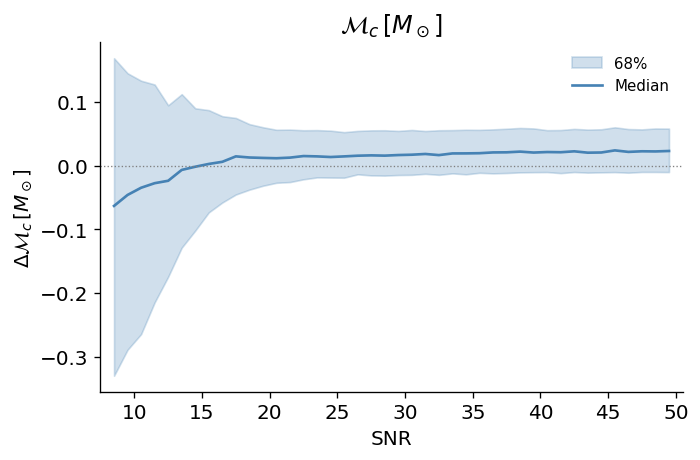

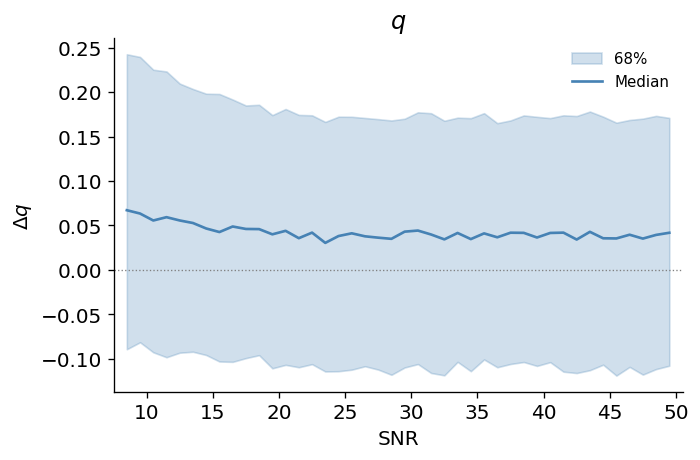

In [8]:
if snr is not None:
    snr_bins    = np.arange(int(np.floor(snr.min())), int(np.ceil(snr.max())) + 1, dtype=float)
    snr_centers = 0.5 * (snr_bins[:-1] + snr_bins[1:])
    snr_a, snr_b = int(snr_bins[0]), int(snr_bins[-1])
    ticks = list(range(5, 51, 5))

    for v in vars_:
        res = residual_d[v]
        med = np.full(len(snr_centers), np.nan)
        q16 = np.full(len(snr_centers), np.nan)
        q84 = np.full(len(snr_centers), np.nan)
        for i, (lo, hi) in enumerate(zip(snr_bins[:-1], snr_bins[1:])):
            m = (snr >= lo) & (snr < hi)
            if m.sum() < 2: continue
            r = res[m]
            med[i] = np.median(r)
            q16[i] = np.percentile(r, 16)
            q84[i] = np.percentile(r, 84)
        valid = ~np.isnan(med); sc = snr_centers[valid]

        fig, ax = plt.subplots(figsize=(6, 4))
        ax.fill_between(sc, q16[valid], q84[valid], alpha=0.25, color='steelblue', label='68%')
        ax.plot(sc, med[valid], color='steelblue', lw=1.6, label='Median')
        ax.axhline(0, color='gray', lw=0.8, ls=':')
        ax.set_xlabel('SNR')
        ax.set_ylabel(r'$\Delta$' + label(v))
        ax.set_title(label(v))
        ax.legend(frameon=False, fontsize=9)
        ax.set_xticks(ticks)
        ax.set_xlim(snr_a - 0.5, snr_b + 0.5)
        fig.tight_layout()
        plt.show()
else:
    print('No SNR column in CSV.')

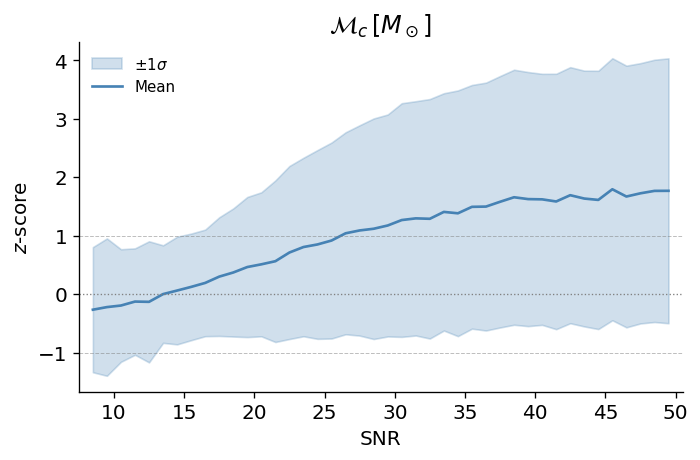

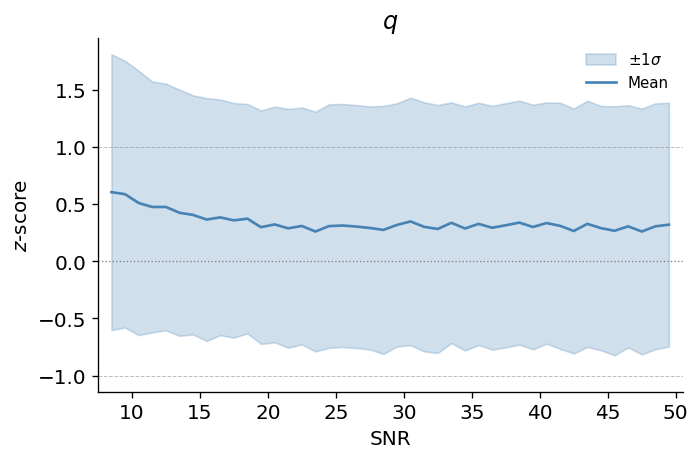

In [9]:
if snr is not None and zscore_d:
    ticks = list(range(5, 51, 5))

    for v in vars_:
        if v not in zscore_d:
            continue
        zs = zscore_d[v]

        zmean = np.full(len(snr_centers), np.nan)
        zstd  = np.full(len(snr_centers), np.nan)

        for i, (lo, hi) in enumerate(zip(snr_bins[:-1], snr_bins[1:])):
            m = (snr >= lo) & (snr < hi)
            if m.sum() < 2: continue
            zmean[i] = np.mean(zs[m])
            zstd[i]  = np.std(zs[m])

        valid = ~np.isnan(zmean); sc = snr_centers[valid]

        fig, ax = plt.subplots(figsize=(6, 4))
        ax.fill_between(sc,
                        zmean[valid] - zstd[valid],
                        zmean[valid] + zstd[valid],
                        alpha=0.25, color='steelblue', label=r'$\pm 1\sigma$')
        ax.plot(sc, zmean[valid], color='steelblue', lw=1.6, label='Mean')
        ax.axhline(0,  color='gray', lw=0.8, ls=':')
        ax.axhline( 1, color='gray', lw=0.6, ls='--', alpha=0.5)
        ax.axhline(-1, color='gray', lw=0.6, ls='--', alpha=0.5)
        ax.set_xlabel('SNR')
        ax.set_ylabel(r'$z$-score')
        ax.set_title(label(v))
        ax.legend(frameon=False, fontsize=9)
        ax.set_xticks(ticks)
        ax.set_xlim(snr_a - 0.5, snr_b + 0.5)
        fig.tight_layout()
        plt.show()
else:
    print('No SNR or z-score columns in CSV.')

## SNR vs Fraction Within Relative-Error Cutoff
Cutoffs: 1%, 5%, 10%, 50%  (|Δ/true| < cutoff).

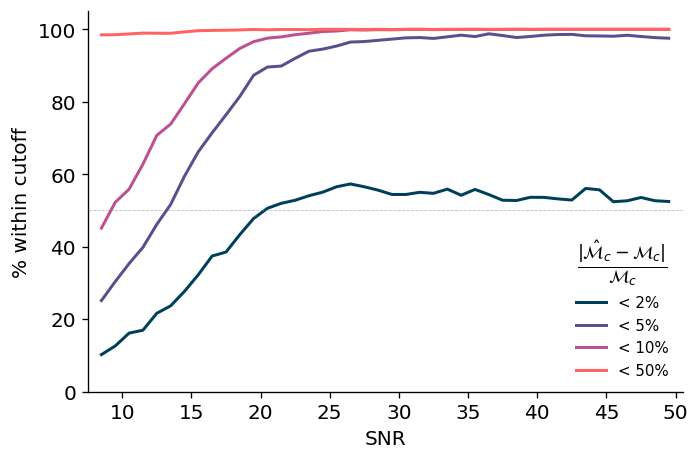

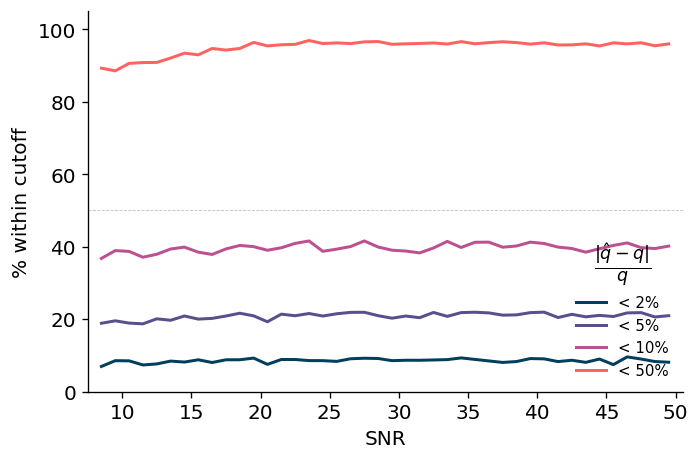

In [10]:
if snr is not None:
    CUTS = [0.02, 0.05, 0.10, 0.50]
    CLRS = ['#003f5c', '#58508d', '#bc5090', '#ff6361']

    LEGEND_TITLES = {
        'chirp_mass': r'$\frac{|\hat{\mathcal{M}}_c - \mathcal{M}_c|}{\mathcal{M}_c}$',
        'mass_ratio': r'$\frac{|\hat{q} - q|}{q}$',
    }

    for v in vars_:
        res     = residual_d[v]
        denom   = np.where(np.abs(true_d[v]) > 1e-8, np.abs(true_d[v]), 1.0)
        rel_err = res / denom

        fig, ax = plt.subplots(figsize=(6, 4))
        for cut, clr in zip(CUTS, CLRS):
            frac = np.full(len(snr_centers), np.nan)
            for i, (lo, hi) in enumerate(zip(snr_bins[:-1], snr_bins[1:])):
                m = (snr >= lo) & (snr < hi)
                if m.sum() > 0:
                    frac[i] = 100.0 * (np.abs(rel_err[m]) < cut).mean()
            valid = ~np.isnan(frac)
            ax.plot(snr_centers[valid], frac[valid], lw=1.8,
                    color=clr, label=f'< {int(cut*100)}%')
        ax.set_xlabel('SNR')
        ax.set_ylabel('% within cutoff')
        ax.axhline(50, color='gray', ls='--', lw=0.5, alpha=0.5)
        ax.legend(frameon=False, fontsize=9, title_fontsize=15,
                  title=LEGEND_TITLES.get(v, r'$\frac{|(\mathrm{pred}-\mathrm{true})|}/{\mathrm{true}}$'),
                  loc='lower right')
        ax.set_xticks(ticks)
        ax.set_xlim(snr_a - 0.5, snr_b + 0.5)
        ax.set_ylim(0, 105)
        fig.tight_layout()
        plt.show()
else:
    print('No SNR column in CSV.')

## Relative Error Violin vs SNR

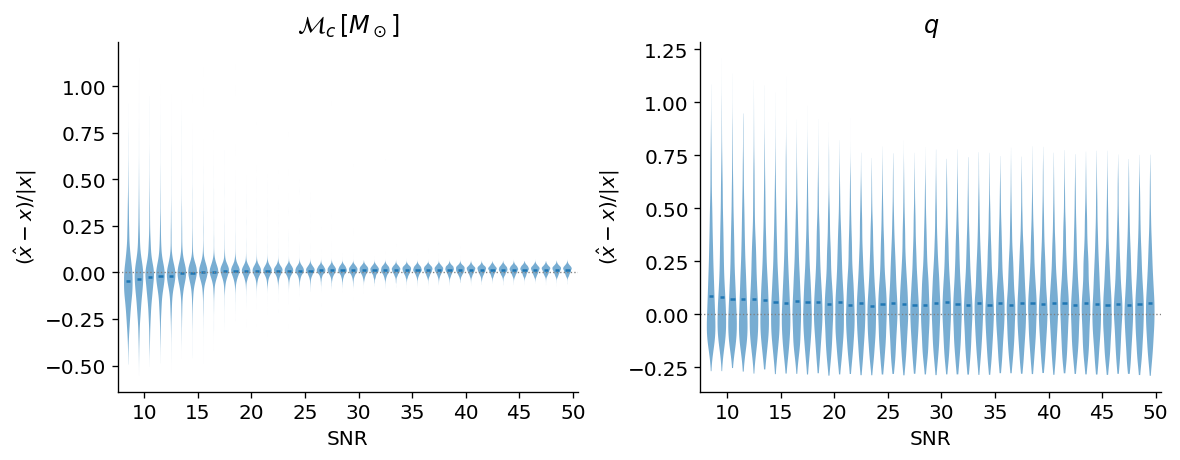

In [11]:
if snr is not None:
    ncols = min(n, 4); nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), squeeze=False)
    for ax, v in zip(axes.flat, vars_):
        res     = residual_d[v]
        denom   = np.where(np.abs(true_d[v]) > 1e-8, np.abs(true_d[v]), 1.0)
        rel_err = res / denom
        groups  = [rel_err[(snr >= snr_bins[i]) & (snr < snr_bins[i+1])]
                   for i in range(len(snr_bins)-1)]
        nonempty = [i for i, g in enumerate(groups) if len(g) > 1]
        if nonempty:
            vp = ax.violinplot([groups[i] for i in nonempty],
                               positions=snr_centers[nonempty], widths=0.8,
                               showmedians=True, showextrema=False)
            for body in vp['bodies']: body.set_alpha(0.6)
        ax.axhline(0, color='gray', lw=0.8, ls=':')
        ax.set_xlabel('SNR'); ax.set_ylabel(r'$(\hat{x}-x)/|x|$')
        ax.set_title(label(v))
        ax.set_xticks(ticks); ax.set_xlim(snr_a - 0.5, snr_b + 0.5)
    for ax in axes.flat[n:]: ax.set_visible(False)
    fig.tight_layout()
    plt.show()
else:
    print('No SNR column in CSV.')

## Background CSV Path

In [12]:
BKG_CSV_SIG = '/n/holystore01/LABS/iaifi_lab/Lab/kyoon/BNSReg/00_AI4GW_TALK/ZZ_misc_outputs/00_AI4GW_TALK/mass_merger_bkg/plots/param_est_results.csv'
df_bkg = pd.read_csv(BKG_CSV_SIG)
print(f'{len(df_bkg):,} background events  |  columns: {list(df_bkg.columns)}')
sigma_bkg = {c.removeprefix('sigma_').removesuffix('_pred'): df_bkg[c].values
             for c in df_bkg.columns if c.startswith('sigma_') and c.endswith('_pred')}


100,000 background events  |  columns: ['chirp_mass_true', 'mass_ratio_true', 'chirp_mass_pred', 'mass_ratio_pred', 'sigma_chirp_mass_pred', 'sigma_mass_ratio_pred', 'chirp_mass_residual', 'mass_ratio_residual', 'chirp_mass_zscore', 'mass_ratio_zscore', 'snr']


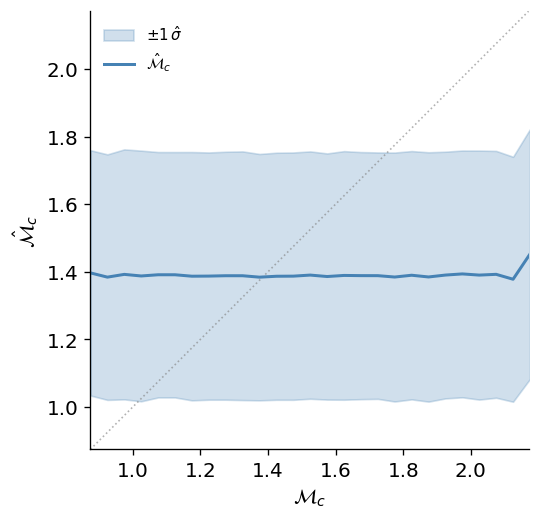

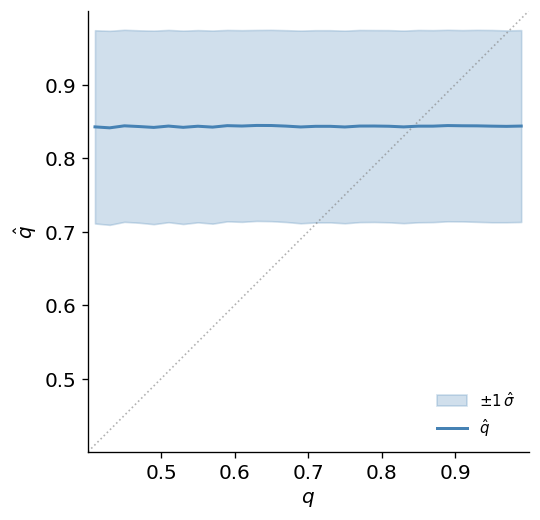

In [13]:
vars_bkg      = [c.replace('_true', '') for c in df_bkg.columns if c.endswith('_true')]
true_d_bkg    = {v: df_bkg[f'{v}_true'].values  for v in vars_bkg}
pred_d_bkg    = {v: df_bkg[f'{v}_pred'].values  for v in vars_bkg}
sigma_d_bkg   = {c.removeprefix('sigma_').removesuffix('_pred'): df_bkg[c].values
                 for c in df_bkg.columns if c.startswith('sigma_') and c.endswith('_pred')}

for v in vars_bkg:
    edges   = bins_for(v, true_d_bkg[v])
    centers = 0.5 * (edges[:-1] + edges[1:])
    tr, pr  = true_d_bkg[v], pred_d_bkg[v]
    sig     = sigma_d_bkg.get(v)

    mean_p    = np.full(len(centers), np.nan)
    mean_sig  = np.full(len(centers), np.nan)

    for i, (lo, hi) in enumerate(zip(edges[:-1], edges[1:])):
        m = (tr >= lo) & (tr < hi)
        if m.sum() < 2: continue
        mean_p[i]   = np.mean(pr[m])
        if sig is not None:
            mean_sig[i] = np.mean(sig[m])

    valid  = ~np.isnan(mean_p)
    lo_d, hi_d = float(tr.min()), float(tr.max())

    fig, ax = plt.subplots(figsize=(5, 4.5))
    ax.plot([lo_d, hi_d], [lo_d, hi_d], color='gray', lw=1.0, ls=':', alpha=0.6)

    if sig is not None and not np.all(np.isnan(mean_sig)):
        ax.fill_between(centers[valid],
                        mean_p[valid] - mean_sig[valid],
                        mean_p[valid] + mean_sig[valid],
                        alpha=0.25, color='steelblue', label=r'$\pm1\,\hat{\sigma}$')
    ax.plot(centers[valid], mean_p[valid], color='steelblue', lw=1.8,
            label=label_hat(v))

    ax.set_xlim(lo_d, hi_d); ax.set_ylim(lo_d, hi_d); ax.set_aspect('equal')
    ax.set_xlabel(label_unitless(v))
    ax.set_ylabel(label_hat(v))
    ax.legend(frameon=False, fontsize=9)
    fig.tight_layout()
    plt.show()


## σ Chirp Mass: Signal vs Background

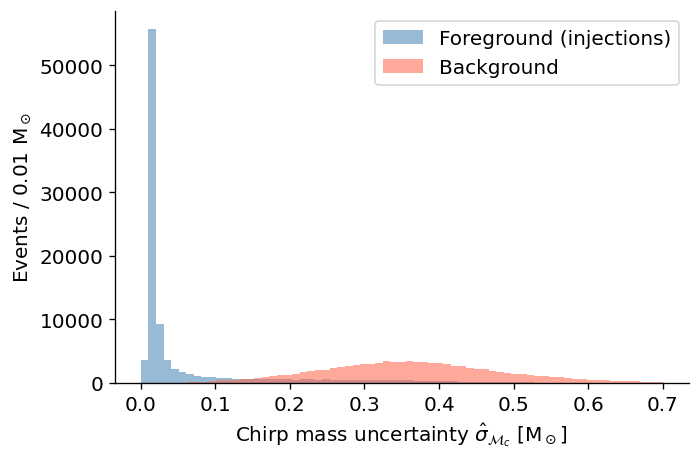

In [14]:
v = 'chirp_mass'
if v in sigma_d and v in sigma_bkg:
    sig_sigma = sigma_d[v]
    bkg_sigma = sigma_bkg[v]
    xmax = 0.7
    bins = np.linspace(0, xmax, 70)
    bw = bins[1] - bins[0]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(sig_sigma, bins=bins, density=False,
            alpha=0.55, color='steelblue', label='Foreground (injections)')
    ax.hist(bkg_sigma, bins=bins, density=False,
            alpha=0.55, color='tomato',    label='Background')
    ax.set_xlabel(r'Chirp mass uncertainty $\hat{\sigma}_{\mathcal{M}_c}$ [$\mathrm{M}_\odot$]')
    ax.set_ylabel(rf'Events / {bw:.2f} $\mathrm{{M}}_\odot$')
    ax.legend(frameon=True)
    fig.tight_layout()
    plt.show()
else:
    print('sigma_chirp_mass_pred not found in one of the CSVs.')

## ROC Curve: σ Chirp Mass as Discriminant
Signal: events below threshold (low uncertainty = confident = signal-like).  
Lower σ → classified as signal.

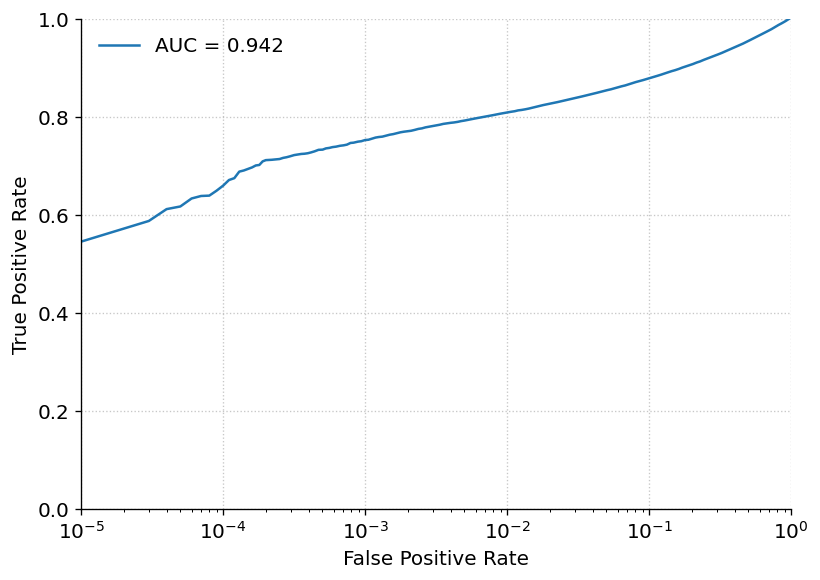

In [15]:
from sklearn.metrics import roc_curve, auc

v = 'chirp_mass'

if v in sigma_d and v in sigma_bkg:

    scores_sig = sigma_d[v]
    scores_bkg = sigma_bkg[v]

    y_score = np.concatenate([-scores_sig, -scores_bkg])
    y_true = np.concatenate([
        np.ones(len(scores_sig)),
        np.zeros(len(scores_bkg))
    ])

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    mask = fpr > 0
    fpr = fpr[mask]
    tpr = tpr[mask]

    # ---- LIGO smoothing trick ----
    bins = np.logspace(np.log10(fpr.min()), 0, 200)

    tpr_smooth = np.zeros(len(bins)-1)
    fpr_smooth = np.zeros(len(bins)-1)

    for i in range(len(bins)-1):

        m = (fpr >= bins[i]) & (fpr < bins[i+1])

        if np.any(m):
            tpr_smooth[i] = tpr[m].max()
            fpr_smooth[i] = np.mean(fpr[m])
        else:
            tpr_smooth[i] = np.nan
            fpr_smooth[i] = np.nan

    valid = ~np.isnan(tpr_smooth)

    fig, ax = plt.subplots(figsize=(7,5))

    ax.plot(fpr_smooth[valid], tpr_smooth[valid],
            lw=1.5,
            label=f'AUC = {roc_auc:.3f}')

    ax.set_xscale('log')
    ax.set_xlim(fpr.min(),1)
    ax.set_ylim(0,1)

    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')

    ax.legend(frameon=False)
    ax.grid(True, ls=':', alpha=0.7)

    plt.tight_layout()
    plt.show()

In [16]:
import os

roc_out_dir = '/n/holystore01/LABS/iaifi_lab/Lab/kyoon/BNSReg/00_AI4GW_TALK/ZZ_misc_outputs/mass_merger_roc'
os.makedirs(roc_out_dir, exist_ok=True)

roc_df = pd.DataFrame({'fpr': fpr_s, 'tpr': tpr_s})
roc_path = os.path.join(roc_out_dir, 'roc_chirp_mass_sigma.csv')
roc_df.to_csv(roc_path, index=False)
print(f'Saved ROC curve to {roc_path}  ({len(roc_df):,} points)')

NameError: name 'fpr_s' is not defined

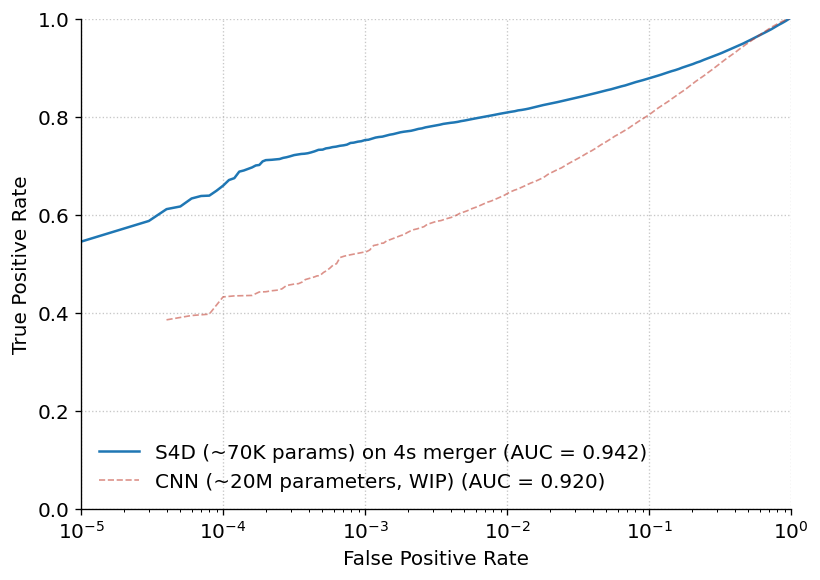

In [19]:
import json

v = 'chirp_mass'

if v in sigma_d and v in sigma_bkg:

    scores_sig = sigma_d[v]
    scores_bkg = sigma_bkg[v]

    y_score = np.concatenate([-scores_sig, -scores_bkg])
    y_true = np.concatenate([
        np.ones(len(scores_sig)),
        np.zeros(len(scores_bkg))
    ])

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    mask = fpr > 0
    fpr = fpr[mask]
    tpr = tpr[mask]

    # ---- LIGO smoothing trick ----
    bins = np.logspace(np.log10(fpr.min()), 0, 200)

    tpr_smooth = np.zeros(len(bins)-1)
    fpr_smooth = np.zeros(len(bins)-1)

    for i in range(len(bins)-1):

        m = (fpr >= bins[i]) & (fpr < bins[i+1])

        if np.any(m):
            tpr_smooth[i] = tpr[m].max()
            fpr_smooth[i] = np.mean(fpr[m])
        else:
            tpr_smooth[i] = np.nan
            fpr_smooth[i] = np.nan

    valid = ~np.isnan(tpr_smooth)

    # ---- baseline benchmark ----
    bmark_path = '/n/holystore01/LABS/iaifi_lab/Lab/kyoon/BNSReg/00_AI4GW_TALK/ZZ_misc_outputs/mass_merger_roc/exp-aframe-time-spec-20s-curriculum-5-epoch.json'
    with open(bmark_path) as f:
        bmark = json.load(f)
    bmark_ytrue  = np.array(bmark['y_true'])
    bmark_yscore = np.array(bmark['y_score_true']).squeeze()

    fpr_b, tpr_b, _ = roc_curve(bmark_ytrue, bmark_yscore)
    auc_b = auc(fpr_b, tpr_b)

    mask_b = fpr_b > 0
    fpr_b = fpr_b[mask_b]
    tpr_b = tpr_b[mask_b]

    bins_b = np.logspace(np.log10(fpr_b.min()), 0, 200)
    tpr_smooth_b = np.zeros(len(bins_b)-1)
    fpr_smooth_b = np.zeros(len(bins_b)-1)
    for i in range(len(bins_b)-1):
        m = (fpr_b >= bins_b[i]) & (fpr_b < bins_b[i+1])
        if np.any(m):
            tpr_smooth_b[i] = tpr_b[m].max()
            fpr_smooth_b[i] = np.mean(fpr_b[m])
        else:
            tpr_smooth_b[i] = np.nan
            fpr_smooth_b[i] = np.nan
    valid_b = ~np.isnan(tpr_smooth_b)

    fig, ax = plt.subplots(figsize=(7,5))

    ax.plot(fpr_smooth[valid], tpr_smooth[valid],
            lw=1.5,
            label=f'S4D (~70K params) on 4s merger (AUC = {roc_auc:.3f})')

    ax.plot(fpr_smooth_b[valid_b], tpr_smooth_b[valid_b],
            lw=1.0, ls='--', color='#c0392b', alpha=0.55,
            # label=f'{bmark["label"]} (AUC = {auc_b:.3f})')
            # label=f'AFRAME-BNS (unpublished, working progress) (AUC = {auc_b:.3f})')
            label=rf'CNN (~20M parameters, WIP) (AUC = {auc_b:.3f})')

    ax.set_xscale('log')
    ax.set_xlim(fpr.min(),1)
    ax.set_ylim(0,1)

    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')

    ax.legend(frameon=False)
    ax.grid(True, ls=':', alpha=0.7)

    plt.tight_layout()
    plt.show()